# Arithmetic Brownian Motion (ABM) vs Geometric Brownian Motion (GBM)

Both are built from standard Brownian motion $W(t)$, but they differ fundamentally in how 
the drift and diffusion scale with the process value.

| | **Arithmetic Brownian Motion (ABM)** | **Geometric Brownian Motion (GBM)** |
|---|---|---|
| **SDE** | $dX = \mu \, dt + \sigma \, dW$ | $dS = \mu S \, dt + \sigma S \, dW$ |
| **Drift** | Constant $\mu$ | Proportional to $S$: $\mu S$ |
| **Volatility** | Constant $\sigma$ | Proportional to $S$: $\sigma S$ |
| **Solution** | $X(t) = X_0 + \mu t + \sigma W(t)$ | $S(t) = S_0 \exp\left[\left(\mu-\frac{\sigma^2}{2}\right)t + \sigma W(t)\right]$ |
| **Distribution** | Normal | Log-Normal |
| **Can go negative?** | **Yes** | **No** (always positive) |
| **Use case** | Interest rates, temperature, spreads | Stock prices, exchange rates, commodities |

> **Key insight:** In GBM, the *percentage* change is random, not the absolute change. 
> This matches how financial markets behave — a \$100 stock and a \$10 stock both move 
> in percentage terms, not dollar terms.


## Arithmetic Brownian Motion

### The SDE

$$dX(t) = \mu \, dt + \sigma \, dW(t)$$

### Exact Solution

Since $dX$ has no $X$ on the right-hand side, we integrate directly:

$$X(t) = X_0 + \int_0^t \mu \, ds + \int_0^t \sigma \, dW(s) = X_0 + \mu t + \sigma W(t)$$

### Statistical Properties

| Property | Formula |
|----------|---------|
| **Mean** | $\mathbb{E}[X(t)] = X_0 + \mu t$ |
| **Variance** | $\text{Var}(X(t)) = \sigma^2 t$ |
| **Distribution** | $X(t) \sim \mathcal{N}(X_0 + \mu t, \; \sigma^2 t)$ |

### The Fatal Flaw

Because $X(t)$ is normally distributed, it has **non-zero probability of being negative**:

$$P(X(t) < 0) = \Phi\left(-\frac{X_0 + \mu t}{\sigma \sqrt{t}}\right) > 0$$

This makes ABM unsuitable for modeling prices, which cannot be negative.


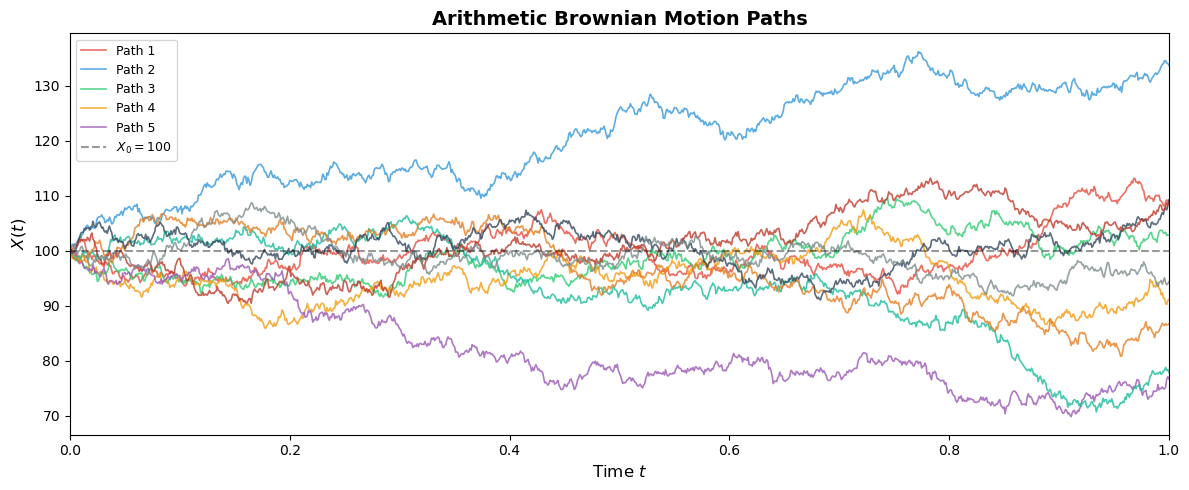

Mean of X(1): 99.037 (theory: 100.050)
Variance of X(1): 269.684 (theory: 225.000)
Std of X(1): 16.422 (theory: 15.000)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def simulate_abm(X0=100, mu=0.05, sigma=15, T=1.0, N=1000, n_paths=5, seed=None):
    """
    Arithmetic Brownian Motion: dX = mu*dt + sigma*dW
    Exact solution: X(t) = X0 + mu*t + sigma*W(t)
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate Brownian motion
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    # ABM exact solution
    X = X0 + mu * t + sigma * W
    
    return t, X

# Simulate ABM
t, X = simulate_abm(X0=100, mu=0.05, sigma=15, T=1.0, N=1000, n_paths=10, seed=42)

# Plot
plt.figure(figsize=(12, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', 
          '#e67e22', '#34495e', '#c0392b', '#7f8c8d']

for i in range(10):
    plt.plot(t, X[i], color=colors[i], alpha=0.8, linewidth=1.2, label=f'Path {i+1}' if i < 5 else None)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, label='$X_0 = 100$')
plt.title('Arithmetic Brownian Motion Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('$X(t)$', fontsize=12)
plt.legend(fontsize=9)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Verify statistics at T=1
print(f"Mean of X(1): {np.mean(X[:, -1]):.3f} (theory: {100 + 0.05*1:.3f})")
print(f"Variance of X(1): {np.var(X[:, -1]):.3f} (theory: {15**2 * 1:.3f})")
print(f"Std of X(1): {np.std(X[:, -1]):.3f} (theory: {15 * np.sqrt(1):.3f})")


## Geometric Brownian Motion

### The SDE

$$\frac{dS(t)}{S(t)} = \mu \, dt + \sigma \, dW(t)$$

The left side is the **instantaneous return** (percentage change). This is the key difference 
from ABM — the random shock scales with the current price level.

### Finding the Exact Solution (Itô's Lemma)

Let $Y(t) = \ln(S(t))$. By Itô's lemma:

$$dY = \frac{1}{S} dS - \frac{1}{2}\frac{1}{S^2}(dS)^2$$

Substitute $dS = \mu S \, dt + \sigma S \, dW$:

$$dY = \mu \, dt + \sigma \, dW - \frac{1}{2}\sigma^2 \, dt = \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma \, dW$$

This is just an ABM for $\ln(S)$! Integrating:

$$\ln(S(t)) = \ln(S_0) + \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)$$

Exponentiating:

$$\boxed{S(t) = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)\right]}$$

### The Itô Correction Term: $-\sigma^2/2$

In ordinary calculus, $d(\ln S) = \frac{dS}{S}$. In stochastic calculus, the second-order term 
$(dW)^2 = dt$ does **not** vanish. The correction ensures:

$$\mathbb{E}[S(t)] = S_0 e^{\mu t}$$

Without it, the expected value would be $S_0 e^{(\mu + \sigma^2/2)t}$ — the volatility would 
artificially inflate the drift!


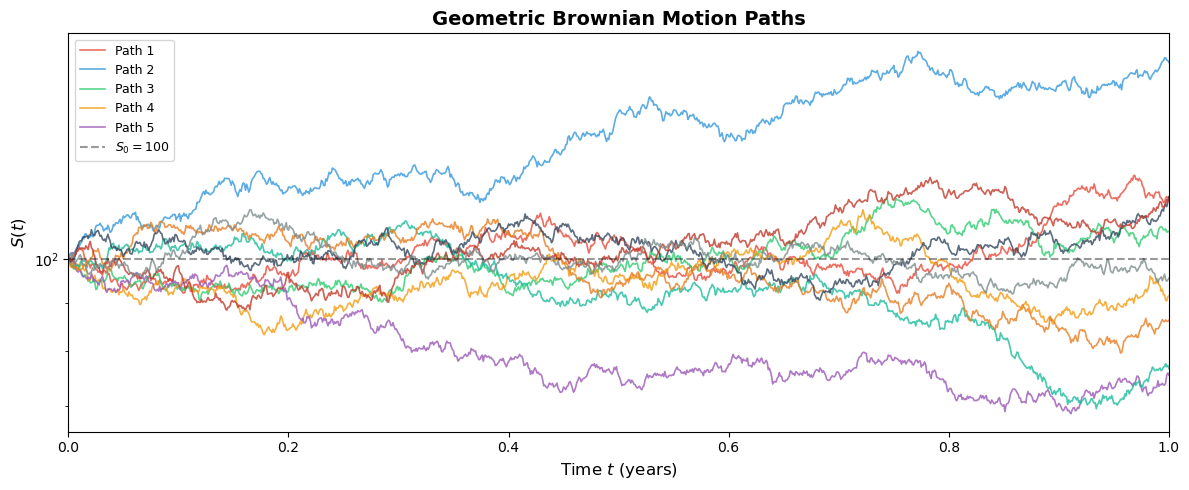

Mean of S(1): 104.213 (theory: 105.127)
Median of S(1): 101.206
Std of S(1): 24.165


In [2]:
def simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=1000, n_paths=5, seed=None):
    """
    Geometric Brownian Motion: dS = mu*S*dt + sigma*S*dW
    Exact solution: S(t) = S0 * exp((mu - sigma^2/2)*t + sigma*W(t))
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate Brownian motion
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    # GBM exact solution
    S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    
    return t, S

# Simulate GBM
t, S = simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=1000, n_paths=10, seed=42)

# Plot
plt.figure(figsize=(12, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', 
          '#e67e22', '#34495e', '#c0392b', '#7f8c8d']

for i in range(10):
    plt.plot(t, S[i], color=colors[i], alpha=0.8, linewidth=1.2, label=f'Path {i+1}' if i < 5 else None)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, label='$S_0 = 100$')
plt.title('Geometric Brownian Motion Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$ (years)', fontsize=12)
plt.ylabel('$S(t)$', fontsize=12)
plt.legend(fontsize=9)
plt.xlim(0, 1)
plt.yscale('log')  # Log scale reveals proportional behavior
plt.tight_layout()
plt.show()

# Verify statistics at T=1
print(f"Mean of S(1): {np.mean(S[:, -1]):.3f} (theory: {100 * np.exp(0.05):.3f})")
print(f"Median of S(1): {np.median(S[:, -1]):.3f}")
print(f"Std of S(1): {np.std(S[:, -1]):.3f}")


## Deep Dive: Statistical Properties

### ABM: $X(t) \sim \mathcal{N}(X_0 + \mu t, \sigma^2 t)$

The distribution is **symmetric** around the mean. The standard deviation grows as $\sqrt{t}$.

### GBM: $S(t) \sim \text{Log-Normal}$

Since $\ln(S(t)) \sim \mathcal{N}\left(\ln(S_0) + (\mu - \sigma^2/2)t, \sigma^2 t\right)$:

| Property | Formula |
|----------|---------|
| **Mean** | $\mathbb{E}[S(t)] = S_0 e^{\mu t}$ |
| **Median** | $S_0 \exp\left[(\mu - \sigma^2/2)t\right]$ |
| **Variance** | $\text{Var}(S(t)) = S_0^2 e^{2\mu t}\left(e^{\sigma^2 t} - 1\right)$ |
| **Mode** | $S_0 \exp\left[(\mu - 3\sigma^2/2)t\right]$ |

### Key Observations

1. **Mean > Median > Mode** for GBM (right-skewed distribution)
2. **ABM variance** grows linearly: $\sigma^2 t$
3. **GBM variance** grows exponentially due to the $e^{\sigma^2 t}$ term
4. **ABM** can model negative values (useful for spreads, interest rates)
5. **GBM** guarantees positivity (essential for prices)
6. 

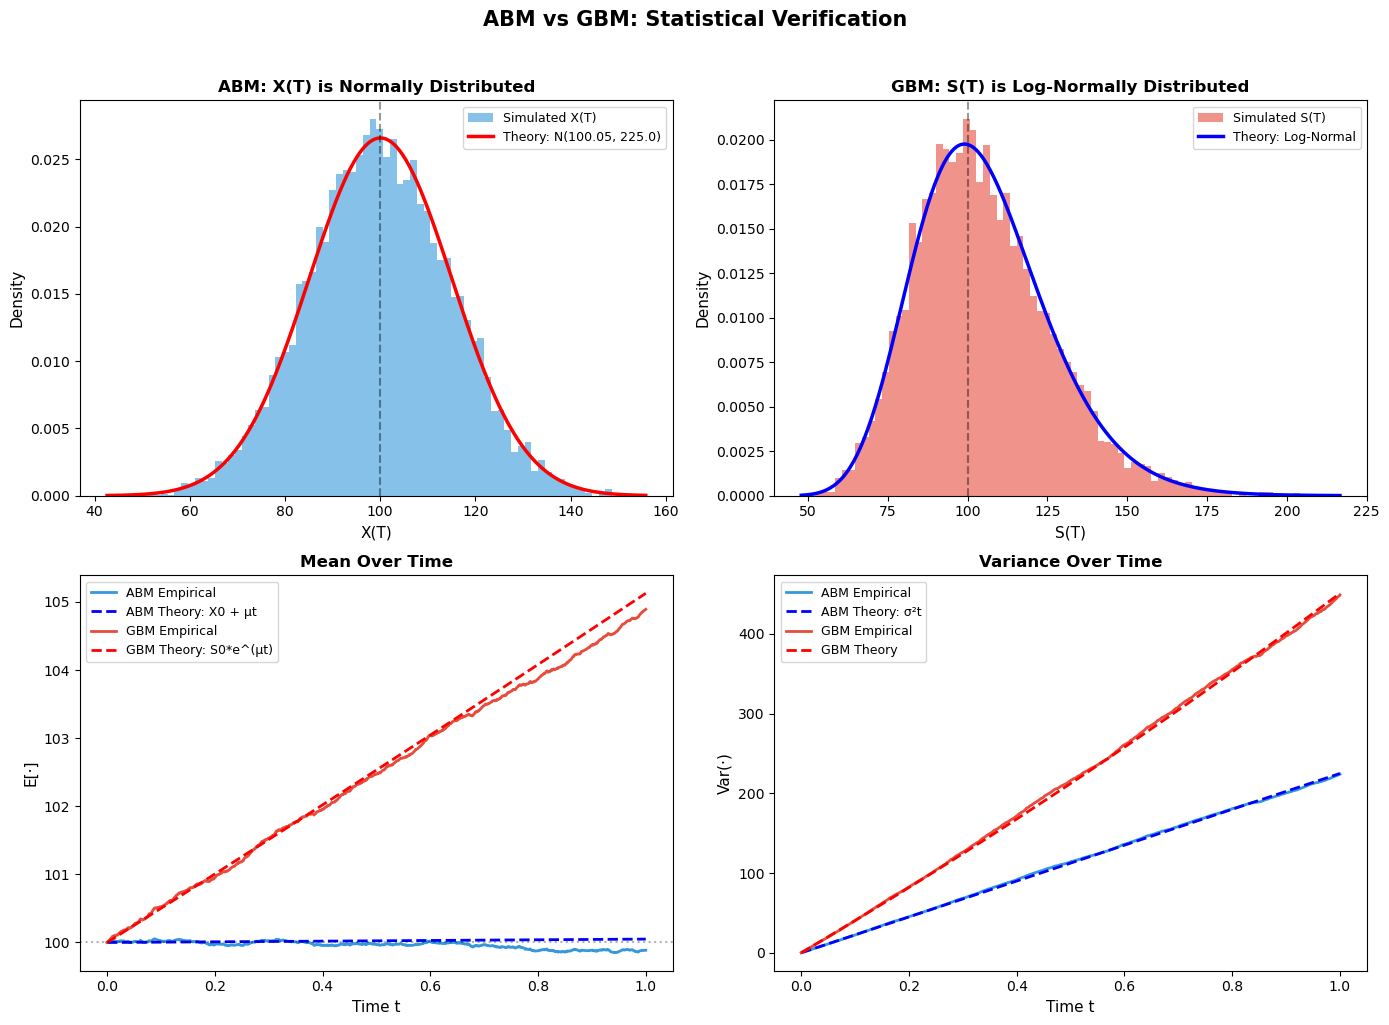

All theoretical formulas verified against simulation!


In [3]:
# Comprehensive distribution verification
np.random.seed(2024)
T, N = 1.0, 1000
n_sims = 10000

# Shared Brownian motion for fair comparison
dt = T / N
dW = np.random.normal(0, np.sqrt(dt), size=(n_sims, N))
W = np.zeros((n_sims, N + 1))
W[:, 1:] = np.cumsum(dW, axis=1)
t = np.linspace(0, T, N + 1)

# Parameters
X0, mu_abm, sigma_abm = 100, 0.05, 15
S0, mu_gbm, sigma_gbm = 100, 0.05, 0.2

# ABM exact
X = X0 + mu_abm * t + sigma_abm * W

# GBM exact
S = S0 * np.exp((mu_gbm - 0.5 * sigma_gbm**2) * t + sigma_gbm * W)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- ABM Distribution at T=1 ---
ax = axes[0, 0]
X_T = X[:, -1]
ax.hist(X_T, bins=80, density=True, alpha=0.6, color='#3498db', label='Simulated X(T)')
theory_mean_abm = X0 + mu_abm * T
theory_std_abm = sigma_abm * np.sqrt(T)
x_range = np.linspace(X_T.min(), X_T.max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, theory_mean_abm, theory_std_abm), 
        'r-', linewidth=2.5, label=f'Theory: N({theory_mean_abm}, {theory_std_abm**2:.1f})')
ax.axvline(x=X0, color='black', linestyle='--', alpha=0.4)
ax.set_title('ABM: X(T) is Normally Distributed', fontsize=12, fontweight='bold')
ax.set_xlabel('X(T)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)

# --- GBM Distribution at T=1 ---
ax = axes[0, 1]
S_T = S[:, -1]
ax.hist(S_T, bins=80, density=True, alpha=0.6, color='#e74c3c', label='Simulated S(T)')
log_mean = np.log(S0) + (mu_gbm - 0.5 * sigma_gbm**2) * T
log_std = sigma_gbm * np.sqrt(T)
x_range = np.linspace(S_T.min(), S_T.max(), 300)
ax.plot(x_range, stats.lognorm.pdf(x_range, s=log_std, scale=np.exp(log_mean)), 
        'b-', linewidth=2.5, label='Theory: Log-Normal')
ax.axvline(x=S0, color='black', linestyle='--', alpha=0.4)
ax.set_title('GBM: S(T) is Log-Normally Distributed', fontsize=12, fontweight='bold')
ax.set_xlabel('S(T)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)

# --- Mean over time ---
ax = axes[1, 0]
ax.plot(t, np.mean(X, axis=0), color='#3498db', linewidth=2, label='ABM Empirical')
ax.plot(t, X0 + mu_abm * t, 'b--', linewidth=2, label='ABM Theory: X0 + μt')
ax.plot(t, np.mean(S, axis=0), color='#e74c3c', linewidth=2, label='GBM Empirical')
ax.plot(t, S0 * np.exp(mu_gbm * t), 'r--', linewidth=2, label='GBM Theory: S0*e^(μt)')
ax.axhline(y=100, color='black', linestyle=':', alpha=0.3)
ax.set_title('Mean Over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t', fontsize=11)
ax.set_ylabel('E[·]', fontsize=11)
ax.legend(fontsize=9)

# --- Variance over time ---
ax = axes[1, 1]
ax.plot(t, np.var(X, axis=0), color='#3498db', linewidth=2, label='ABM Empirical')
ax.plot(t, (sigma_abm**2) * t, 'b--', linewidth=2, label='ABM Theory: σ²t')
ax.plot(t, np.var(S, axis=0), color='#e74c3c', linewidth=2, label='GBM Empirical')
theory_var_gbm = (S0**2) * np.exp(2 * mu_gbm * t) * (np.exp(sigma_gbm**2 * t) - 1)
ax.plot(t, theory_var_gbm, 'r--', linewidth=2, label='GBM Theory')
ax.set_title('Variance Over Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t', fontsize=11)
ax.set_ylabel('Var(·)', fontsize=11)
ax.legend(fontsize=9)

plt.suptitle('ABM vs GBM: Statistical Verification', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("All theoretical formulas verified against simulation!")


## Why ABM Fails for Stock Prices

The probability that $X(t) < 0$ is:

$$P(X(t) < 0) = \Phi\left(-\frac{X_0 + \mu t}{\sigma \sqrt{t}}\right)$$

Where $\Phi$ is the standard normal CDF.

For $X_0 = 10$, $\mu = 0$, $\sigma = 8$, $t = 1$:

$$P(X(1) < 0) = \Phi\left(-\frac{10}{8}\right) = \Phi(-1.25) \approx 0.106$$

So about **10.6%** of paths go negative! This is catastrophic for price modeling.

### Real-World Analogy

- **ABM** = modeling temperature in Celsius (can go negative)
- **GBM** = modeling stock price in dollars (cannot go negative)

ABM *is* used for:
- Interest rates (can be negative in some economies)
- Temperature modeling
- Spread between two assets
- Ornstein-Uhlenbeck process (mean-reverting ABM)
- 

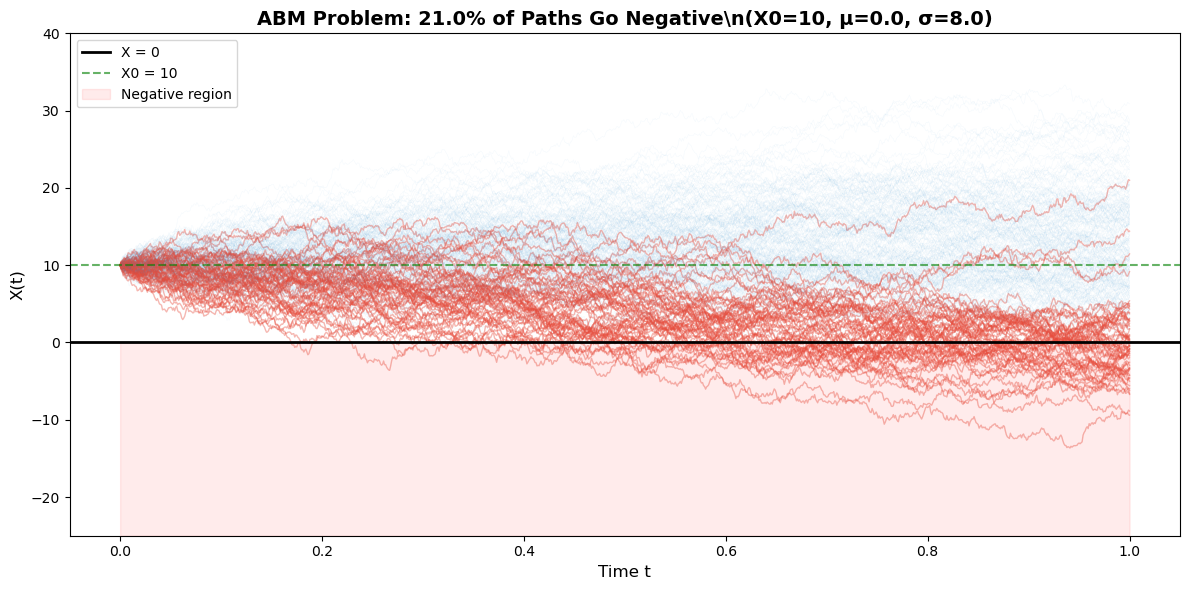

Empirical probability of going negative: 0.2100
Theoretical probability: 0.1056


In [4]:
# Dramatic demonstration of ABM going negative
np.random.seed(55)
T, N = 1.0, 1000
dt = T / N
n_paths = 300

# Use parameters where negative values are common
X0, mu_abm, sigma_abm = 10, 0.0, 8.0

dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
W = np.zeros((n_paths, N + 1))
W[:, 1:] = np.cumsum(dW, axis=1)
t = np.linspace(0, T, N + 1)
X = X0 + mu_abm * t + sigma_abm * W

neg_mask = np.any(X < 0, axis=1)
neg_count = np.sum(neg_mask)
neg_pct = 100 * neg_count / n_paths

plt.figure(figsize=(12, 6))
for i in range(n_paths):
    color = '#e74c3c' if neg_mask[i] else '#3498db'
    alpha = 0.4 if neg_mask[i] else 0.05
    lw = 1.0 if neg_mask[i] else 0.4
    plt.plot(t, X[i], color=color, alpha=alpha, linewidth=lw)

plt.axhline(y=0, color='black', linestyle='-', linewidth=2, label='X = 0')
plt.axhline(y=X0, color='green', linestyle='--', alpha=0.6, label=f'X0 = {X0}')
plt.fill_between(t, -25, 0, alpha=0.08, color='red', label='Negative region')
plt.title(f'ABM Problem: {neg_pct:.1f}% of Paths Go Negative\\n'
          f'(X0={X0}, μ={mu_abm}, σ={sigma_abm})', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time t', fontsize=12)
plt.ylabel('X(t)', fontsize=12)
plt.legend(fontsize=10)
plt.ylim(-25, 40)
plt.tight_layout()
plt.show()

# Theoretical probability
from scipy.stats import norm
theory_prob = norm.cdf(-(X0 + mu_abm * T) / (sigma_abm * np.sqrt(T)))
print(f"Empirical probability of going negative: {neg_pct/100:.4f}")
print(f"Theoretical probability: {theory_prob:.4f}")


## Numerical Solution: Euler-Maruyama Method

When an SDE has no closed-form solution, we use **Euler-Maruyama discretization**:

$$X(t_{i+1}) = X(t_i) + \mu(X_i, t_i)\Delta t + \sigma(X_i, t_i)\Delta W_i$$

### For GBM:

$$S(t_{i+1}) = S(t_i) + \mu S(t_i)\Delta t + \sigma S(t_i)\Delta W_i$$

$$= S(t_i)\left[1 + \mu\Delta t + \sigma\Delta W_i\right]$$

### Convergence

The **strong error** (path-wise) converges at rate $O(\sqrt{\Delta t}) = O(1/\sqrt{N})$.

The **weak error** (distribution-wise) converges at rate $O(\Delta t) = O(1/N)$.

> **Tip:** For GBM, always use the **exact solution** if possible — it's faster and more accurate. 
> Euler-Maruyama is needed for more complex SDEs (e.g., with stochastic volatility).


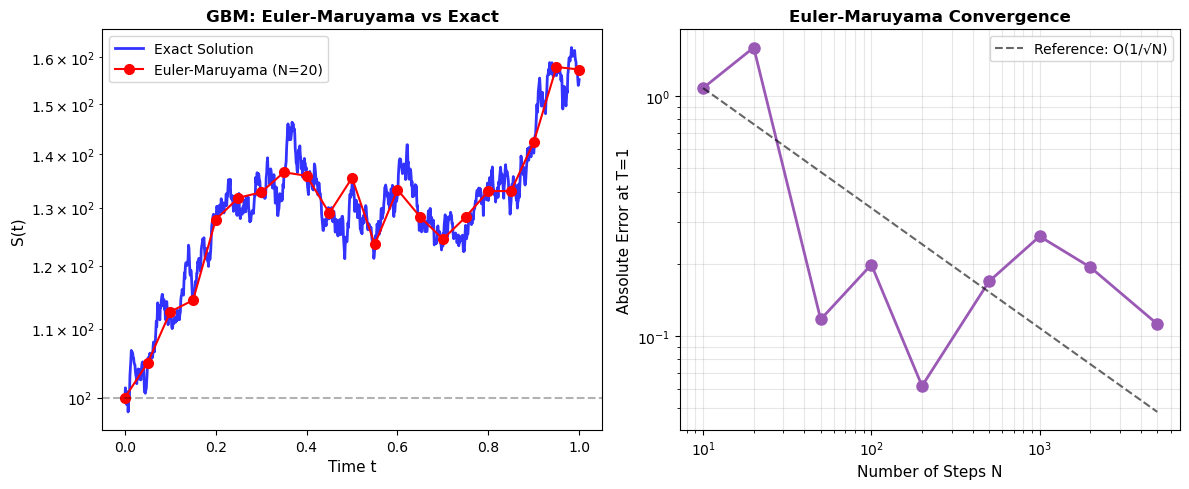

In [5]:
# Compare Euler-Maruyama with exact solution
np.random.seed(66)
S0, mu, sigma = 100, 0.05, 0.3
T = 1.0
N_exact = 1000
N_euler = 20  # Coarse grid

# Exact solution (fine grid)
dt_fine = T / N_exact
dW_fine = np.random.normal(0, np.sqrt(dt_fine), N_exact)
W_fine = np.cumsum(dW_fine)
t_fine = np.linspace(0, T, N_exact + 1)
S_exact = S0 * np.exp((mu - 0.5 * sigma**2) * t_fine + sigma * np.concatenate([[0], W_fine]))

# Euler-Maruyama (coarse grid — same Brownian path)
dt_coarse = T / N_euler
step = N_exact // N_euler
dW_coarse = np.array([np.sum(dW_fine[i*step:(i+1)*step]) for i in range(N_euler)])
t_coarse = np.linspace(0, T, N_euler + 1)

S_euler = np.zeros(N_euler + 1)
S_euler[0] = S0
for i in range(N_euler):
    S_euler[i+1] = S_euler[i] + mu * S_euler[i] * dt_coarse + sigma * S_euler[i] * dW_coarse[i]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_fine, S_exact, 'b-', linewidth=2, alpha=0.8, label='Exact Solution')
plt.plot(t_coarse, S_euler, 'ro-', markersize=7, linewidth=1.5, 
         label=f'Euler-Maruyama (N={N_euler})')
plt.axhline(y=S0, color='black', linestyle='--', alpha=0.3)
plt.title('GBM: Euler-Maruyama vs Exact', fontsize=12, fontweight='bold')
plt.xlabel('Time t', fontsize=11)
plt.ylabel('S(t)', fontsize=11)
plt.legend(fontsize=10)
plt.yscale('log')

# Convergence analysis
plt.subplot(1, 2, 2)
np.random.seed(77)
N_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
errors = []

# One fixed fine path for reference
dW_ref = np.random.normal(0, np.sqrt(T/10000), 10000)
W_ref = np.cumsum(dW_ref)
S_ref_T = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_ref[-1])

for N in N_values:
    dt = T / N
    step = 10000 // N
    dW_c = np.array([np.sum(dW_ref[i*step:(i+1)*step]) for i in range(N)])
    
    S_e = np.zeros(N + 1)
    S_e[0] = S0
    for i in range(N):
        S_e[i+1] = S_e[i] + mu * S_e[i] * dt + sigma * S_e[i] * dW_c[i]
    
    errors.append(abs(S_e[-1] - S_ref_T))

plt.loglog(N_values, errors, 'o-', markersize=8, linewidth=2, color='#9b59b6')
ref = [errors[0] * (N_values[0]/N)**0.5 for N in N_values]
plt.loglog(N_values, ref, 'k--', linewidth=1.5, alpha=0.6, label='Reference: O(1/√N)')
plt.title('Euler-Maruyama Convergence', fontsize=12, fontweight='bold')
plt.xlabel('Number of Steps N', fontsize=11)
plt.ylabel('Absolute Error at T=1', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


## Log-Returns: The Workhorse of Quantitative Finance

For GBM, the **log-return** over a small interval $\Delta t$ is:

$$r_t = \ln\left(\frac{S(t+\Delta t)}{S(t)}\right) = \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \Delta W_t$$

### Properties of Log-Returns

| Property | Value |
|----------|-------|
| **Distribution** | $\mathcal{N}\left((\mu - \sigma^2/2)\Delta t, \sigma^2 \Delta t\right)$ |
| **Mean** | $(\mu - \sigma^2/2)\Delta t$ |
| **Variance** | $\sigma^2 \Delta t$ |
| **Independence** | Independent across time (by construction) |

### Why Log-Returns?

1. **Additivity**: $\ln(S_T/S_0) = \sum_{i=1}^{N} \ln(S_i/S_{i-1})$
2. **Symmetry**: A $+10\%$ and $-10\%$ return cancel in log space
3. **Normality**: Easier to model and test statistically
4. **Time aggregation**: Variance scales linearly with time

### Simple Returns vs Log-Returns

| | Simple Return | Log-Return |
|---|---|---|
| **Formula** | $(S_{t+1} - S_t)/S_t$ | $\ln(S_{t+1}/S_t)$ |
| **Additivity** | No | Yes |
| **Range** | $[-1, \infty)$ | $(-\infty, \infty)$ |
| **For small returns** | $\approx$ log-return | Exact |


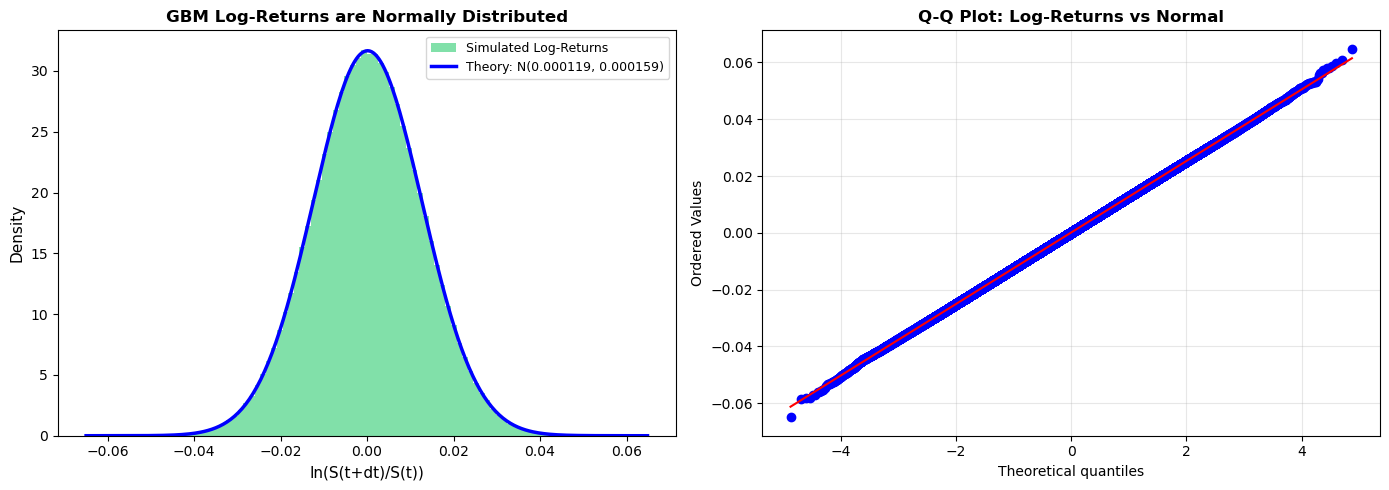

Empirical mean of log-returns: 0.00012542
Theoretical mean: 0.00011905
Empirical std of log-returns: 0.01259132
Theoretical std: 0.01259882
Annualized volatility estimate: 0.1999 (true: 0.2000)


In [6]:
# Analyze log-returns of GBM
np.random.seed(88)
S0, mu, sigma = 100, 0.05, 0.2
T, N = 1.0, 252  # 252 trading days
dt = T / N

t, S = simulate_gbm(S0, mu, sigma, T, N, n_paths=5000, seed=88)

# Compute log-returns
log_returns = np.log(S[:, 1:] / S[:, :-1]).flatten()

# Theoretical parameters
theory_mean = (mu - 0.5 * sigma**2) * dt
theory_std = sigma * np.sqrt(dt)

plt.figure(figsize=(14, 5))

# Histogram of log-returns
plt.subplot(1, 2, 1)
plt.hist(log_returns, bins=100, density=True, alpha=0.6, color='#2ecc71', 
         label='Simulated Log-Returns')
x_range = np.linspace(log_returns.min(), log_returns.max(), 300)
plt.plot(x_range, stats.norm.pdf(x_range, theory_mean, theory_std), 
         'b-', linewidth=2.5, label=f'Theory: N({theory_mean:.6f}, {theory_std**2:.6f})')
plt.title('GBM Log-Returns are Normally Distributed', fontsize=12, fontweight='bold')
plt.xlabel('ln(S(t+dt)/S(t))', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=9)

# Q-Q plot against normal
plt.subplot(1, 2, 2)
stats.probplot(log_returns, dist="norm", plot=plt)
plt.title('Q-Q Plot: Log-Returns vs Normal', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Empirical mean of log-returns: {np.mean(log_returns):.8f}")
print(f"Theoretical mean: {theory_mean:.8f}")
print(f"Empirical std of log-returns: {np.std(log_returns):.8f}")
print(f"Theoretical std: {theory_std:.8f}")
print(f"Annualized volatility estimate: {np.std(log_returns) * np.sqrt(252):.4f} (true: {sigma:.4f})")


## Complete Formula Reference

### Standard Brownian Motion
- $W(0) = 0$
- $W(t) - W(s) \sim \mathcal{N}(0, t-s)$
- $\text{Var}(W(t)) = t$

### Arithmetic Brownian Motion
- **SDE**: $dX = \mu \, dt + \sigma \, dW$
- **Solution**: $X(t) = X_0 + \mu t + \sigma W(t)$
- **Mean**: $\mathbb{E}[X(t)] = X_0 + \mu t$
- **Variance**: $\text{Var}(X(t)) = \sigma^2 t$
- **Distribution**: $X(t) \sim \mathcal{N}(X_0 + \mu t, \sigma^2 t)$

### Geometric Brownian Motion
- **SDE**: $dS = \mu S \, dt + \sigma S \, dW$
- **Solution**: $S(t) = S_0 \exp\left[(\mu - \sigma^2/2)t + \sigma W(t)\right]$
- **Mean**: $\mathbb{E}[S(t)] = S_0 e^{\mu t}$
- **Variance**: $\text{Var}(S(t)) = S_0^2 e^{2\mu t}(e^{\sigma^2 t} - 1)$
- **Distribution**: $\ln(S(t)) \sim \mathcal{N}\left(\ln(S_0) + (\mu - \sigma^2/2)t, \sigma^2 t\right)$

### Euler-Maruyama Discretization
- **General**: $X_{i+1} = X_i + \mu(X_i, t_i)\Delta t + \sigma(X_i, t_i)\sqrt{\Delta t} Z_i$
- **Strong convergence**: $O(\sqrt{\Delta t})$
- **Weak convergence**: $O(\Delta t)$
- 

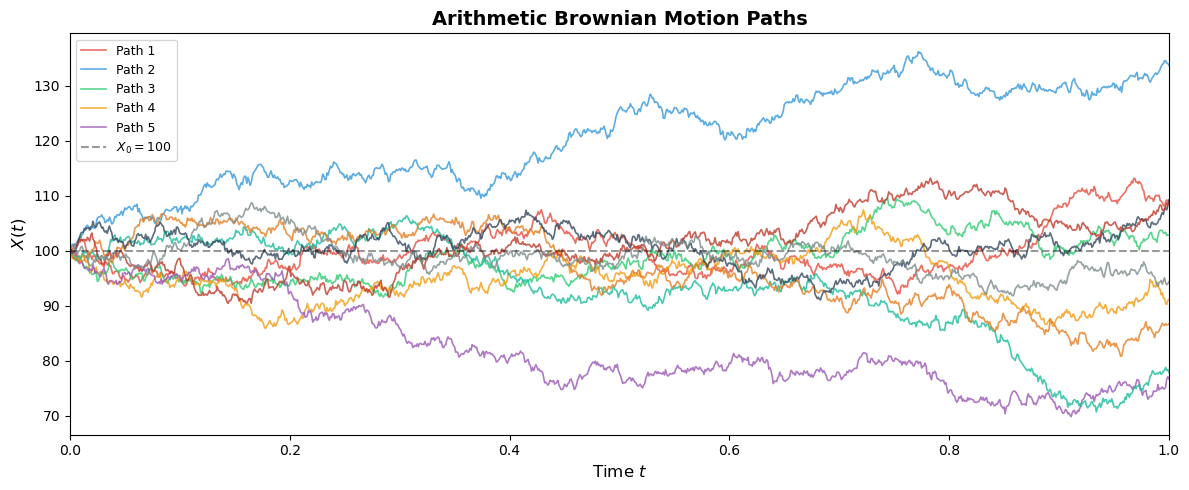

Mean of X(1): 99.037 (theory: 100.050)
Variance of X(1): 269.684 (theory: 225.000)
Std of X(1): 16.422 (theory: 15.000)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def simulate_abm(X0=100, mu=0.05, sigma=15, T=1.0, N=1000, n_paths=5, seed=None):
    """
    Arithmetic Brownian Motion: dX = mu*dt + sigma*dW
    Exact solution: X(t) = X0 + mu*t + sigma*W(t)
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate Brownian motion
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    # ABM exact solution
    X = X0 + mu * t + sigma * W
    
    return t, X

# Simulate ABM
t, X = simulate_abm(X0=100, mu=0.05, sigma=15, T=1.0, N=1000, n_paths=10, seed=42)

# Plot
plt.figure(figsize=(12, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', 
          '#e67e22', '#34495e', '#c0392b', '#7f8c8d']

for i in range(10):
    plt.plot(t, X[i], color=colors[i], alpha=0.8, linewidth=1.2, label=f'Path {i+1}' if i < 5 else None)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, label='$X_0 = 100$')
plt.title('Arithmetic Brownian Motion Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('$X(t)$', fontsize=12)
plt.legend(fontsize=9)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Verify statistics at T=1
print(f"Mean of X(1): {np.mean(X[:, -1]):.3f} (theory: {100 + 0.05*1:.3f})")
print(f"Variance of X(1): {np.var(X[:, -1]):.3f} (theory: {15**2 * 1:.3f})")
print(f"Std of X(1): {np.std(X[:, -1]):.3f} (theory: {15 * np.sqrt(1):.3f})")


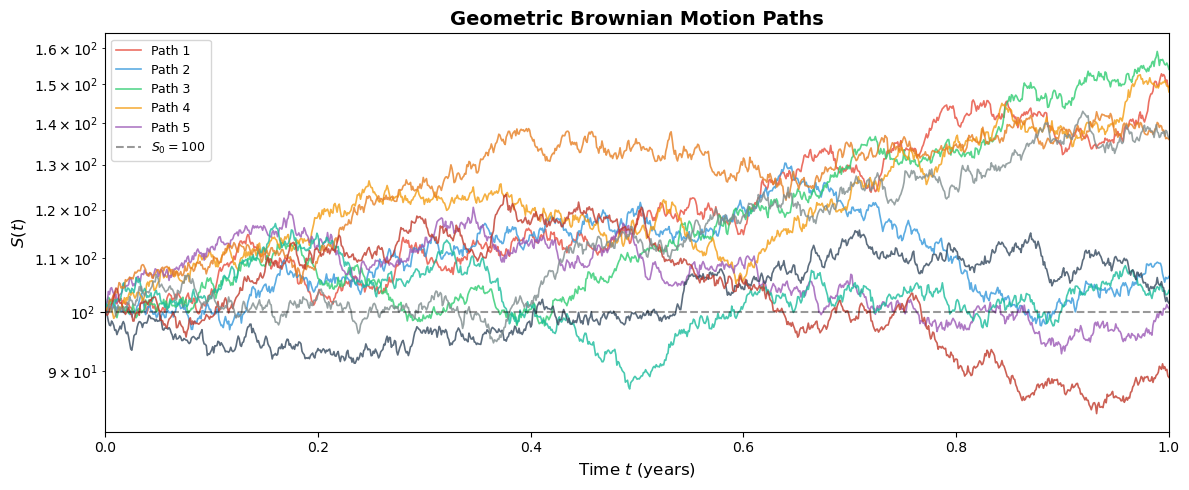

Mean of S(1): 122.506 (theory: 105.127)
Median of S(1): 121.230
Std of S(1): 23.173


In [7]:
def simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=1000, n_paths=5, seed=None):
    """
    Geometric Brownian Motion: dS = mu*S*dt + sigma*S*dW
    Exact solution: S(t) = S0 * exp((mu - sigma^2/2)*t + sigma*W(t))
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate Brownian motion
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    # GBM exact solution
    S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    
    return t, S

# Simulate GBM
t, S = simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=1000, n_paths=10, seed=99)

# Plot
plt.figure(figsize=(12, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', 
          '#e67e22', '#34495e', '#c0392b', '#7f8c8d']

for i in range(10):
    plt.plot(t, S[i], color=colors[i], alpha=0.8, linewidth=1.2, label=f'Path {i+1}' if i < 5 else None)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, label='$S_0 = 100$')
plt.title('Geometric Brownian Motion Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$ (years)', fontsize=12)
plt.ylabel('$S(t)$', fontsize=12)
plt.legend(fontsize=9)
plt.xlim(0, 1)
plt.yscale('log')  # Log scale reveals proportional behavior
plt.tight_layout()
plt.show()

# Verify statistics at T=1
print(f"Mean of S(1): {np.mean(S[:, -1]):.3f} (theory: {100 * np.exp(0.05):.3f})")
print(f"Median of S(1): {np.median(S[:, -1]):.3f}")
print(f"Std of S(1): {np.std(S[:, -1]):.3f}")


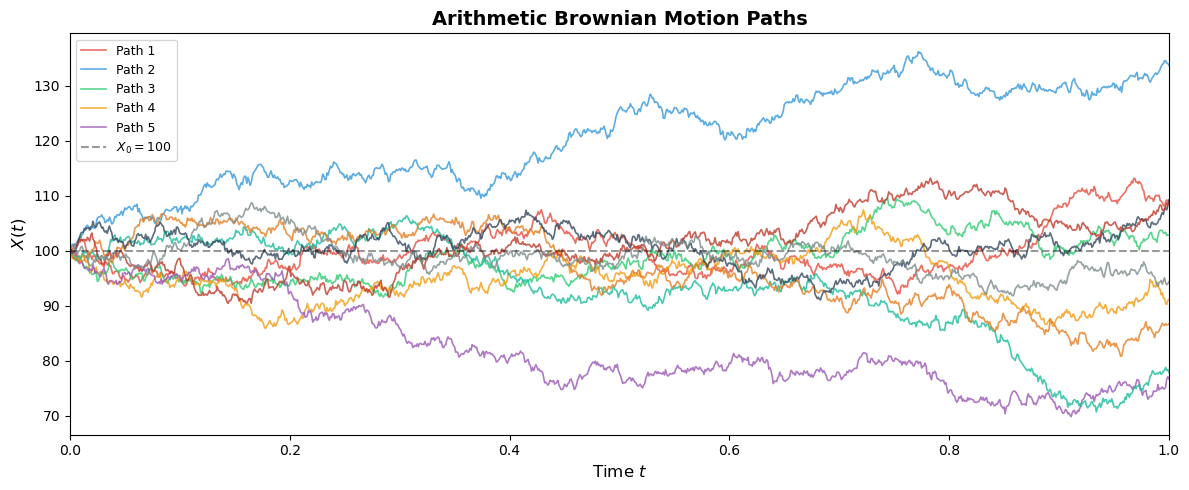

Mean of X(1): 99.037 (theory: 100.050)
Variance of X(1): 269.684 (theory: 225.000)
Std of X(1): 16.422 (theory: 15.000)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def make_brownian_motion(T=1.0, N=1000, n_paths=1, seed=None):
    """Generate Brownian motion W(t)."""
    if seed is not None:
        np.random.seed(seed)
    dt = T / N
    t = np.linspace(0, T, N + 1)
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    return t, W

def abm_from_w(W, t, X0=100, mu=0.05, sigma=15):
    """ABM using pre-generated W."""
    return X0 + mu * t + sigma * W

# Generate ONE W
t, W = make_brownian_motion(T=1.0, N=1000, n_paths=5, seed=42)

# Apply to both models
X = abm_from_w(W, t, X0=100, mu=0.05, sigma=15)    

# Simulate ABM
t, X = simulate_abm(X0=100, mu=0.05, sigma=15, T=1.0, N=1000, n_paths=10, seed=42)

# Plot
plt.figure(figsize=(12, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', 
          '#e67e22', '#34495e', '#c0392b', '#7f8c8d']

for i in range(10):
    plt.plot(t, X[i], color=colors[i], alpha=0.8, linewidth=1.2, label=f'Path {i+1}' if i < 5 else None)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, label='$X_0 = 100$')
plt.title('Arithmetic Brownian Motion Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('$X(t)$', fontsize=12)
plt.legend(fontsize=9)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Verify statistics at T=1
print(f"Mean of X(1): {np.mean(X[:, -1]):.3f} (theory: {100 + 0.05*1:.3f})")
print(f"Variance of X(1): {np.var(X[:, -1]):.3f} (theory: {15**2 * 1:.3f})")
print(f"Std of X(1): {np.std(X[:, -1]):.3f} (theory: {15 * np.sqrt(1):.3f})")


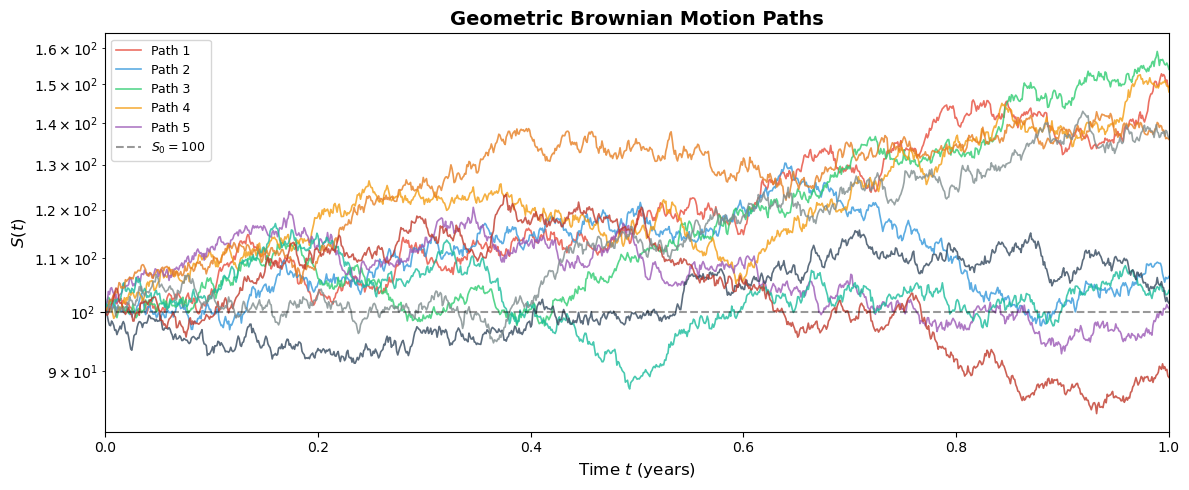

Mean of S(1): 122.506 (theory: 105.127)
Median of S(1): 121.230
Std of S(1): 23.173


In [10]:
def make_brownian_motion(T=1.0, N=1000, n_paths=1, seed=None):
    """Generate Brownian motion W(t)."""
    if seed is not None:
        np.random.seed(seed)
    dt = T / N
    t = np.linspace(0, T, N + 1)
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    return t, W

def gbm_from_w(W, t, S0=100, mu=0.05, sigma=0.2):
    """GBM using pre-generated W."""
    return S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

# Generate ONE W
t, W = make_brownian_motion(T=1.0, N=1000, n_paths=5, seed=42)

# Apply to both models
S = gbm_from_w(W, t, S0=100, mu=0.05, sigma=0.2)

# Simulate GBM
t, S = simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1.0, N=1000, n_paths=10, seed=99)

# Plot
plt.figure(figsize=(12, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', 
          '#e67e22', '#34495e', '#c0392b', '#7f8c8d']

for i in range(10):
    plt.plot(t, S[i], color=colors[i], alpha=0.8, linewidth=1.2, label=f'Path {i+1}' if i < 5 else None)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, label='$S_0 = 100$')
plt.title('Geometric Brownian Motion Paths', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$ (years)', fontsize=12)
plt.ylabel('$S(t)$', fontsize=12)
plt.legend(fontsize=9)
plt.xlim(0, 1)
plt.yscale('log')  # Log scale reveals proportional behavior
plt.tight_layout()
plt.show()

# Verify statistics at T=1
print(f"Mean of S(1): {np.mean(S[:, -1]):.3f} (theory: {100 * np.exp(0.05):.3f})")
print(f"Median of S(1): {np.median(S[:, -1]):.3f}")
print(f"Std of S(1): {np.std(S[:, -1]):.3f}")


In [8]:
import numpy as np

def make_brownian_motion(T=1.0, N=1000, n_paths=1, seed=None):
    """Generate Brownian motion W(t)."""
    if seed is not None:
        np.random.seed(seed)
    dt = T / N
    t = np.linspace(0, T, N + 1)
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    return t, W

def abm_from_w(W, t, X0=100, mu=0.05, sigma=15):
    """ABM using pre-generated W."""
    return X0 + mu * t + sigma * W

def gbm_from_w(W, t, S0=100, mu=0.05, sigma=0.2):
    """GBM using pre-generated W."""
    return S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

# Generate ONE W
t, W = make_brownian_motion(T=1.0, N=1000, n_paths=5, seed=42)

# Apply to both models
X = abm_from_w(W, t, X0=100, mu=0.05, sigma=15)
S = gbm_from_w(W, t, S0=100, mu=0.05, sigma=0.2)

# Now X and S share the same W for fair comparison
